# 02 - Analyse des profils TomTom: summaries & segments

**Thèse :** Explainable LLM Framework for Tourist-Traffic Forecasting in Phuket  
**Auteur :** Mathieu Zilli  
**Date :** Avril 2026

**V9 note:** ce notebook reste une brique descriptive amont. Il est **réutilisé tel quel** dans la branche V9 pour comprendre les profils journaliers TomTom, les timesets les plus informatifs et les structures de congestion qui motivent ensuite les features de mémoire trafic.

---

## Objectifs
1. Analyser les profils TomTom bruts (summaries_all.csv + segments_all.csv)
2. Visualiser le profil journalier complet (24 timesets) par corridor
3. Analyser les distributions percentile de vitesse et temps de trajet (P5→P95)
4. Analyser le PTI (Planning Time Index) - fiabilité du réseau
5. Évolution temporelle mensuelle (2023-2024, 24 mois)
6. Analyse des segments - goulots d'étranglement par tronçon

## Données
> `summaries_all.csv` : 2304 lignes = 4 corridors × 24 mois × 24 timesets  
> `segments_all.csv`  : 537 408 lignes = segments individuels de chaque corridor


## 0. Setup


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200,
                     'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa'})

CORRIDOR_COLORS = {
    'Airport Road (Route 402)'        : '#2196F3',
    'Patong Hill (Route 4029)'         : '#F44336',
    'Phuket Town to Rawai (Route 4022)': '#4CAF50',
    'Bypass Road (Route 4027)'         : '#FF9800',
}
CORRIDOR_SHORT = {
    'Airport Road (Route 402)'        : 'Airport',
    'Patong Hill (Route 4029)'         : 'Patong',
    'Phuket Town to Rawai (Route 4022)': 'Town→Rawai',
    'Bypass Road (Route 4027)'         : 'Bypass',
}
CORRIDORS_ORDER = list(CORRIDOR_SHORT.keys())

# Ordre chronologique des timesets weekday et weekend
WEEKDAY_ORDER = [
    'Weekday_Night', 'Weekday_Early', 'Weekday_AM1', 'Weekday_AM2',
    'Weekday_Morning', 'Weekday_Midday', 'Weekday_Afternoon', 'Weekday_PrePM',
    'Weekday_PM1', 'Weekday_PM2', 'Weekday_Evening', 'Weekday_LateNight',
]
WEEKDAY_LABELS = ['00-04h','05-06h','07h','08h','09-11h','12-13h',
                  '14-15h','16h','17h','18h','19-21h','22-23h']
WEEKEND_ORDER = [ts.replace('Weekday_','Weekend_') for ts in WEEKDAY_ORDER]

ALL_TIMESETS = WEEKDAY_ORDER + WEEKEND_ORDER  # 24 total

SEASON_ORDER  = ['high_peak','shoulder','monsoon']
SEASON_LABELS = {
    'high_peak': 'High season (Dec-Mar)',
    'shoulder':  'Shoulder',
    'monsoon':   'Monsoon (Jun-Oct)',
}

print('Setup OK')

Setup OK


## 1. Chargement des données TomTom


In [87]:
df_sum = pd.read_csv('../tomtom_phuket/processed/summaries_all.csv')
df_seg = pd.read_csv('../tomtom_phuket/processed/segments_all.csv')

# Enrichir summaries
df_sum['corridor_short'] = df_sum['route_name'].map(CORRIDOR_SHORT)
df_sum['year']           = df_sum['daterange_name'].str[:4].astype(int)
df_sum['month']          = df_sum['daterange_name'].str[5:7].astype(int)
df_sum['month_date']     = pd.to_datetime(df_sum[['year','month']].assign(day=1))
df_sum['is_weekday']     = df_sum['timeset_name'].str.startswith('Weekday')

# Saison
def get_season(m):
    if m in [12,1,2,3]: return 'high_peak'
    if m in [4,5,11]:   return 'shoulder'
    return 'monsoon'
df_sum['season'] = df_sum['month'].apply(get_season)

print(f"summaries_all.csv : {df_sum.shape[0]:,} lignes × {df_sum.shape[1]} cols")
print(f"  Corridors  : {df_sum['route_name'].nunique()} - {sorted(df_sum['route_name'].unique())}")
print(f"  Month       : {df_sum['daterange_name'].nunique()} ({df_sum['daterange_name'].min()} → {df_sum['daterange_name'].max()})")
print(f"  Timesets   : {df_sum['timeset_name'].nunique()} - {sorted(df_sum['timeset_name'].unique())}")
print(f"  NaN        : {df_sum.isnull().sum().sum()}")
print()
print(f"segments_all.csv  : {df_seg.shape[0]:,} lignes × {df_seg.shape[1]} cols")
print(f"  Timesets   : {sorted(df_seg['timeset_name'].unique())}")
df_sum[['route_name','timeset_name','daterange_name','harmonic_avg_speed',
        'avg_travel_time_ratio','planning_time_index']].head(5)


summaries_all.csv : 2,304 lignes × 63 cols
  Corridors  : 4 - ['Airport Road (Route 402)', 'Bypass Road (Route 4027)', 'Patong Hill (Route 4029)', 'Phuket Town to Rawai (Route 4022)']
  Month       : 24 (2023_01 → 2024_12)
  Timesets   : 24 - ['Weekday_AM1', 'Weekday_AM2', 'Weekday_Afternoon', 'Weekday_Early', 'Weekday_Evening', 'Weekday_LateNight', 'Weekday_Midday', 'Weekday_Morning', 'Weekday_Night', 'Weekday_PM1', 'Weekday_PM2', 'Weekday_PrePM', 'Weekend_AM1', 'Weekend_AM2', 'Weekend_Afternoon', 'Weekend_Early', 'Weekend_Evening', 'Weekend_LateNight', 'Weekend_Midday', 'Weekend_Morning', 'Weekend_Night', 'Weekend_PM1', 'Weekend_PM2', 'Weekend_PrePM']
  NaN        : 0

segments_all.csv  : 537,408 lignes × 52 cols
  Timesets   : ['Weekday_AM1', 'Weekday_AM2', 'Weekday_Afternoon', 'Weekday_Early', 'Weekday_Evening', 'Weekday_LateNight', 'Weekday_Midday', 'Weekday_Morning', 'Weekday_Night', 'Weekday_PM1', 'Weekday_PM2', 'Weekday_PrePM', 'Weekend_AM1', 'Weekend_AM2', 'Weekend_Afternoon',

,route_name,timeset_name,daterange_name,harmonic_avg_speed,avg_travel_time_ratio,planning_time_index
0,Airport Road (Route 402),Weekday_Night,2023_01,54.91,1.00,1.76
1,Airport Road (Route 402),Weekday_Early,2023_01,50.00,1.10,2.10
2,Airport Road (Route 402),Weekday_AM1,2023_01,47.39,1.14,2.17
3,Airport Road (Route 402),Weekday_AM2,2023_01,44.75,1.23,2.33
4,Airport Road (Route 402),Weekday_Morning,2023_01,44.28,1.25,2.38


## 2. Profil journalier complet (24 timesets)

> Courbe heure par heure de la vitesse harmonique et du TTR par corridor.  
> Moyenne sur les 24 mois disponibles (2023-2024).


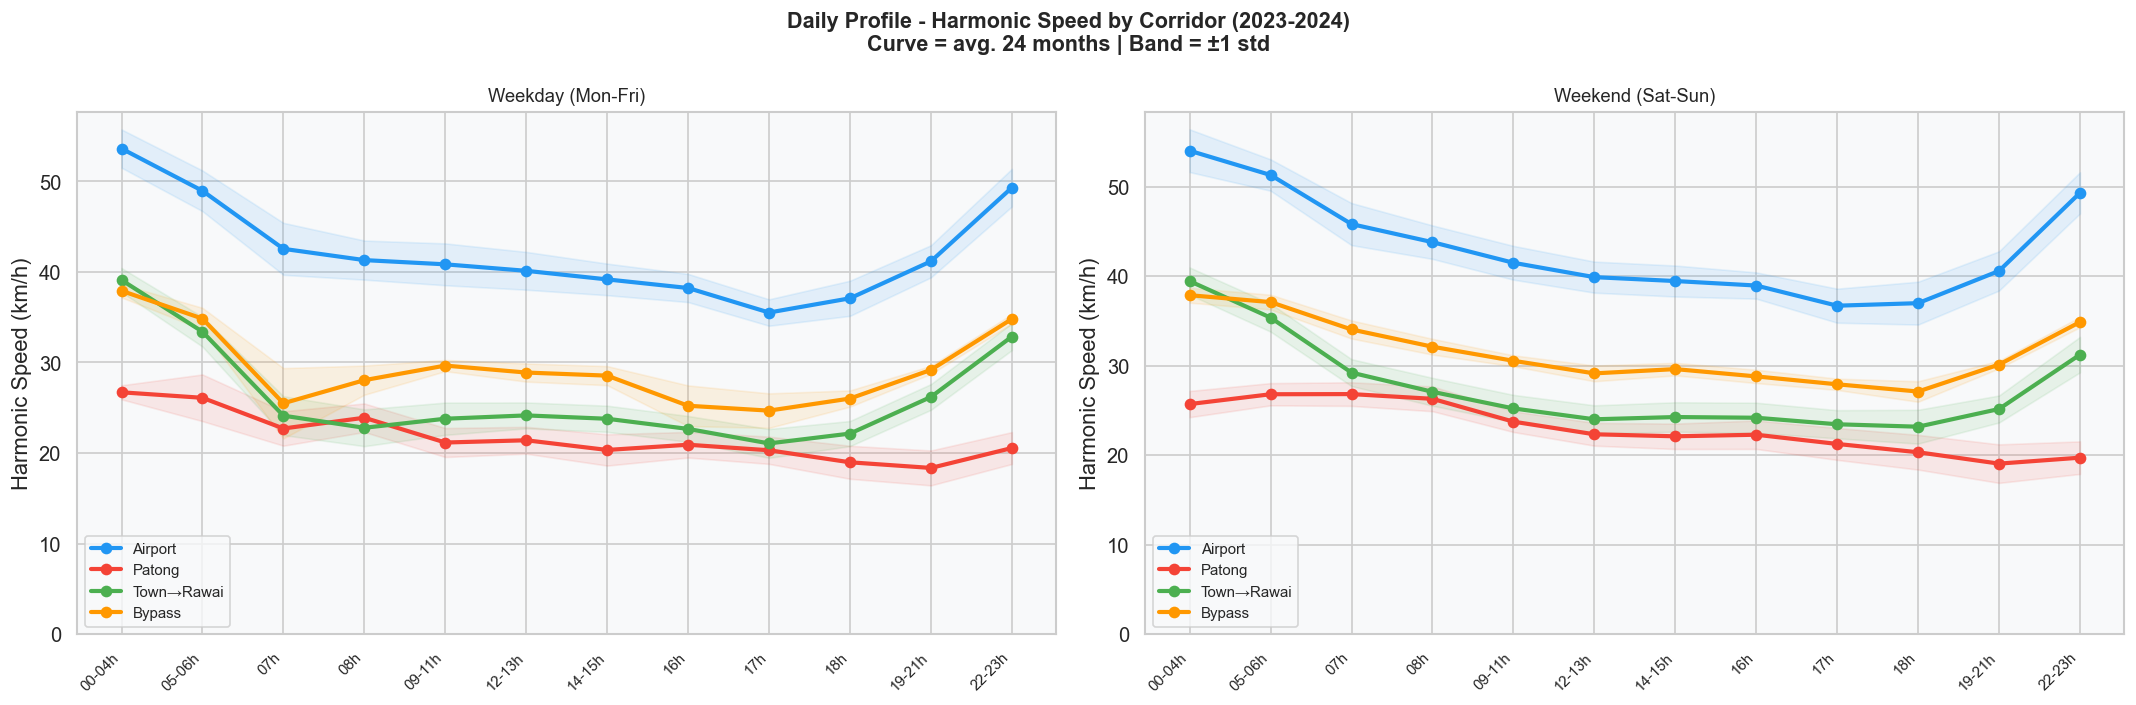

In [88]:
# Daily profile - harmonic speed
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Daily Profile - Harmonic Speed by Corridor (2023-2024)\n'
             'Curve = avg. 24 months | Band = ±1 std', fontsize=13, fontweight='bold')

for ax, (order, labels, title) in zip(axes, [
    (WEEKDAY_ORDER, WEEKDAY_LABELS, 'Weekday (Mon-Fri)'),
    (WEEKEND_ORDER, WEEKDAY_LABELS, 'Weekend (Sat-Sun)'),
]):
    for corr in CORRIDORS_ORDER:
        sub   = df_sum[df_sum['route_name']==corr]
        means = [sub[sub['timeset_name']==ts]['harmonic_avg_speed'].mean() for ts in order]
        stds  = [sub[sub['timeset_name']==ts]['harmonic_avg_speed'].std()  for ts in order]
        x = range(len(order))
        ax.plot(x, means, 'o-', linewidth=2.5, markersize=6,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
        ax.fill_between(x, [m-s for m,s in zip(means,stds)],
                           [m+s for m,s in zip(means,stds)],
                        alpha=0.1, color=CORRIDOR_COLORS[corr])
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Harmonic Speed (km/h)')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_profiles_speed.png', bbox_inches='tight', facecolor='white')
plt.show()

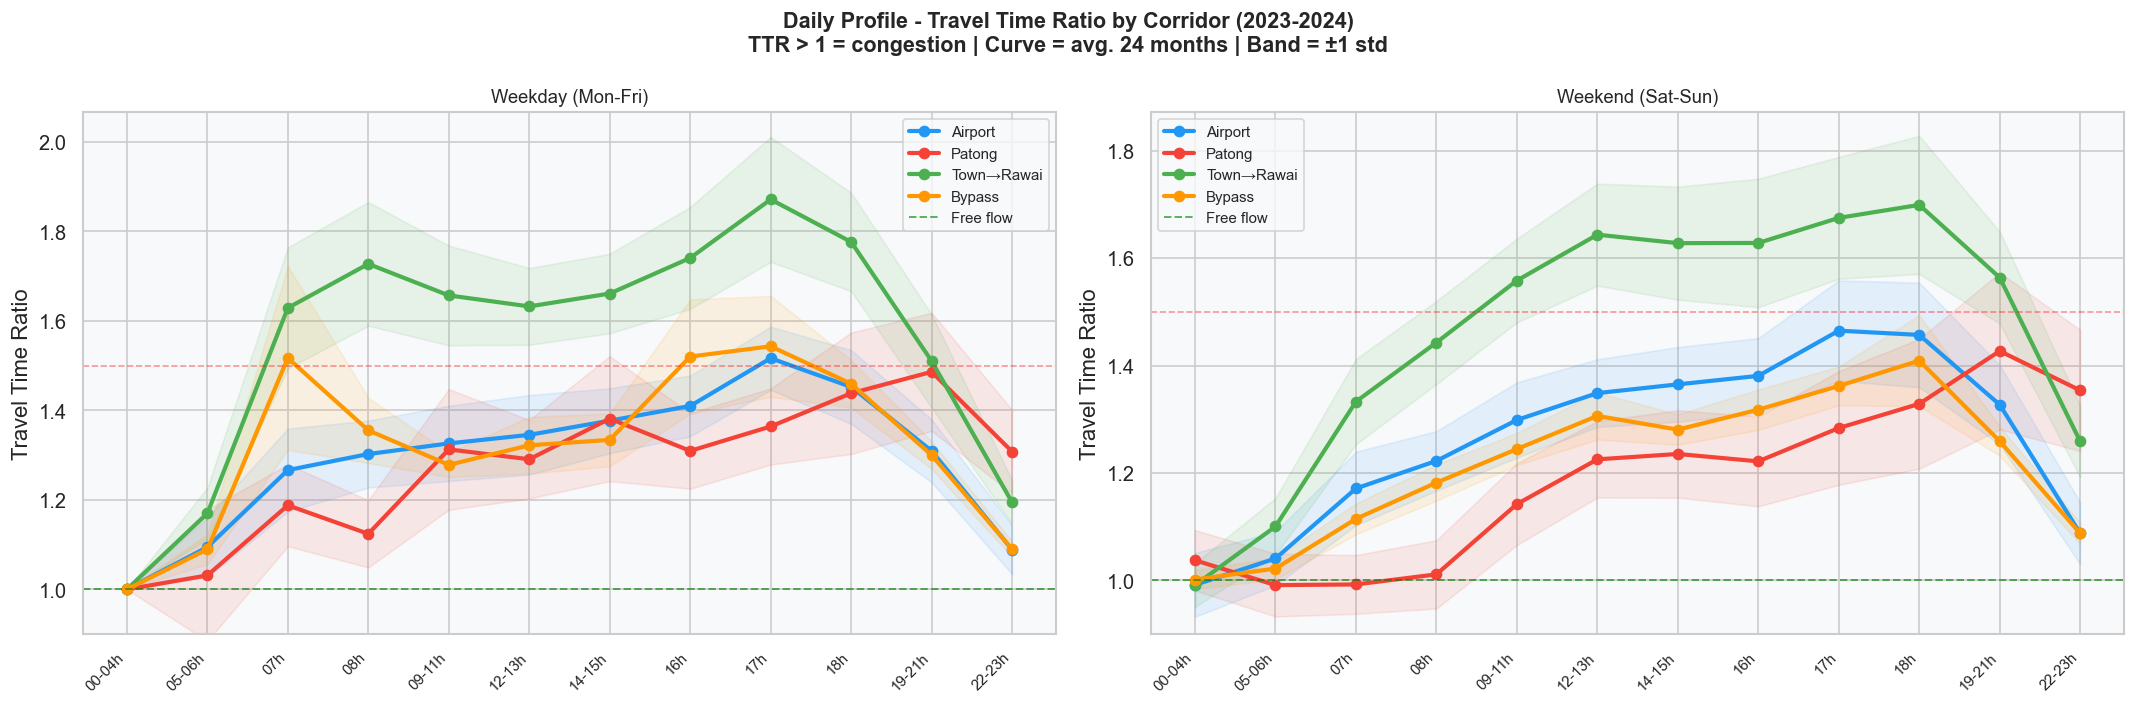

In [89]:
# Daily profile - Travel Time Ratio
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Daily Profile - Travel Time Ratio by Corridor (2023-2024)\n'
             'TTR > 1 = congestion | Curve = avg. 24 months | Band = ±1 std', fontsize=13, fontweight='bold')

for ax, (order, labels, title) in zip(axes, [
    (WEEKDAY_ORDER, WEEKDAY_LABELS, 'Weekday (Mon-Fri)'),
    (WEEKEND_ORDER, WEEKDAY_LABELS, 'Weekend (Sat-Sun)'),
]):
    for corr in CORRIDORS_ORDER:
        sub   = df_sum[df_sum['route_name']==corr]
        means = [sub[sub['timeset_name']==ts]['avg_travel_time_ratio'].mean() for ts in order]
        stds  = [sub[sub['timeset_name']==ts]['avg_travel_time_ratio'].std()  for ts in order]
        x = range(len(order))
        ax.plot(x, means, 'o-', linewidth=2.5, markersize=6,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
        ax.fill_between(x, [m-s for m,s in zip(means,stds)],
                           [m+s for m,s in zip(means,stds)],
                        alpha=0.1, color=CORRIDOR_COLORS[corr])
    ax.axhline(1.0, color='green', linestyle='--', linewidth=1.2, alpha=0.6, label='Free flow')
    ax.axhline(1.5, color='red',   linestyle='--', linewidth=1,   alpha=0.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Travel Time Ratio')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0.9)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_profiles_ttr.png', bbox_inches='tight', facecolor='white')
plt.show()

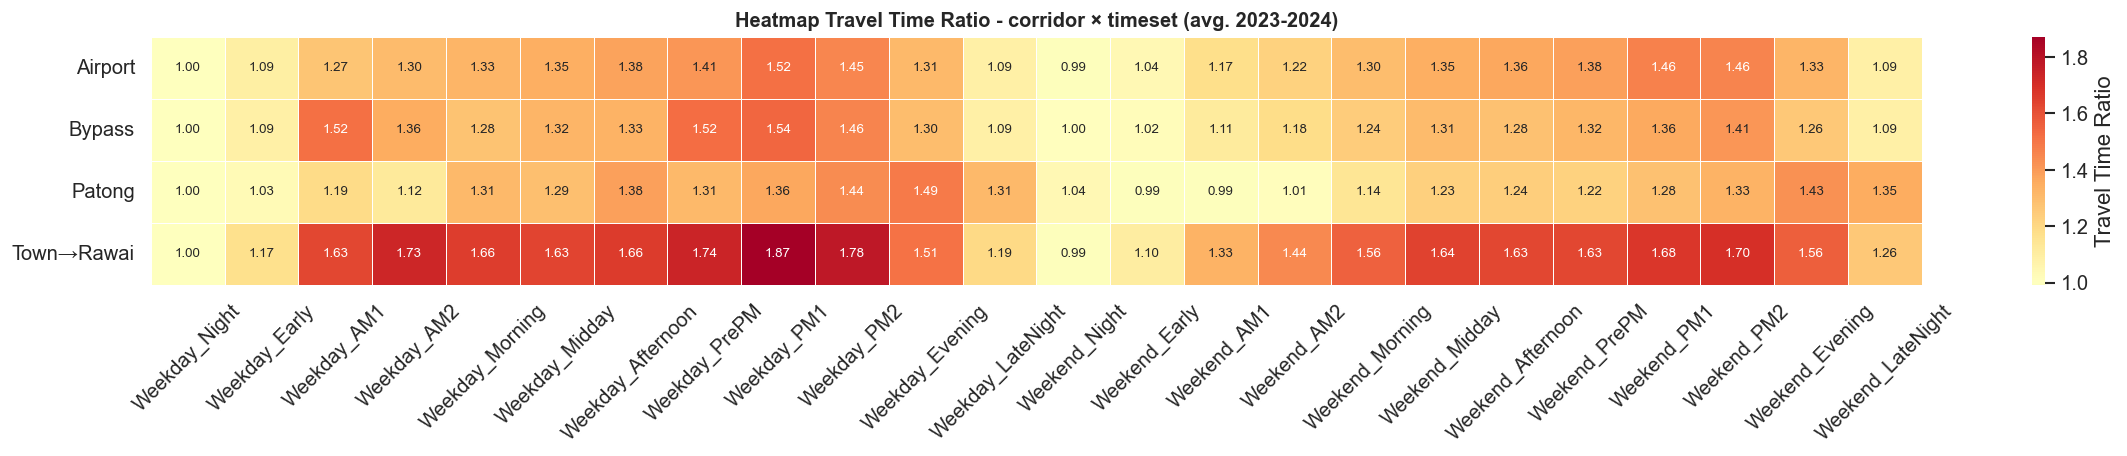

In [90]:
# Heatmap TTR - corridor × timeset (moyenne 2023-2024)
pivot_ttr = df_sum.groupby(['route_name','timeset_name'])['avg_travel_time_ratio'].mean().unstack()
# Réordonner colonnes
pivot_ttr = pivot_ttr[ALL_TIMESETS]
pivot_ttr.index = [CORRIDOR_SHORT[c] for c in pivot_ttr.index]

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(pivot_ttr, ax=ax, cmap='RdYlGn_r', center=1.0,
            annot=True, fmt='.2f', annot_kws={'size':8},
            linewidths=0.5, cbar_kws={'label':'Travel Time Ratio'})
ax.set_title('Heatmap Travel Time Ratio - corridor × timeset (avg. 2023-2024)', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../final_data/figures/fig_heatmap_ttr.png', bbox_inches='tight')
plt.show()


## 3. Courbes de percentiles de vitesse (P5 → P95)

Distribution complète des vitesses enregistrées.  
Écart P5-P95 important → forte variabilité (congestion imprévisible).


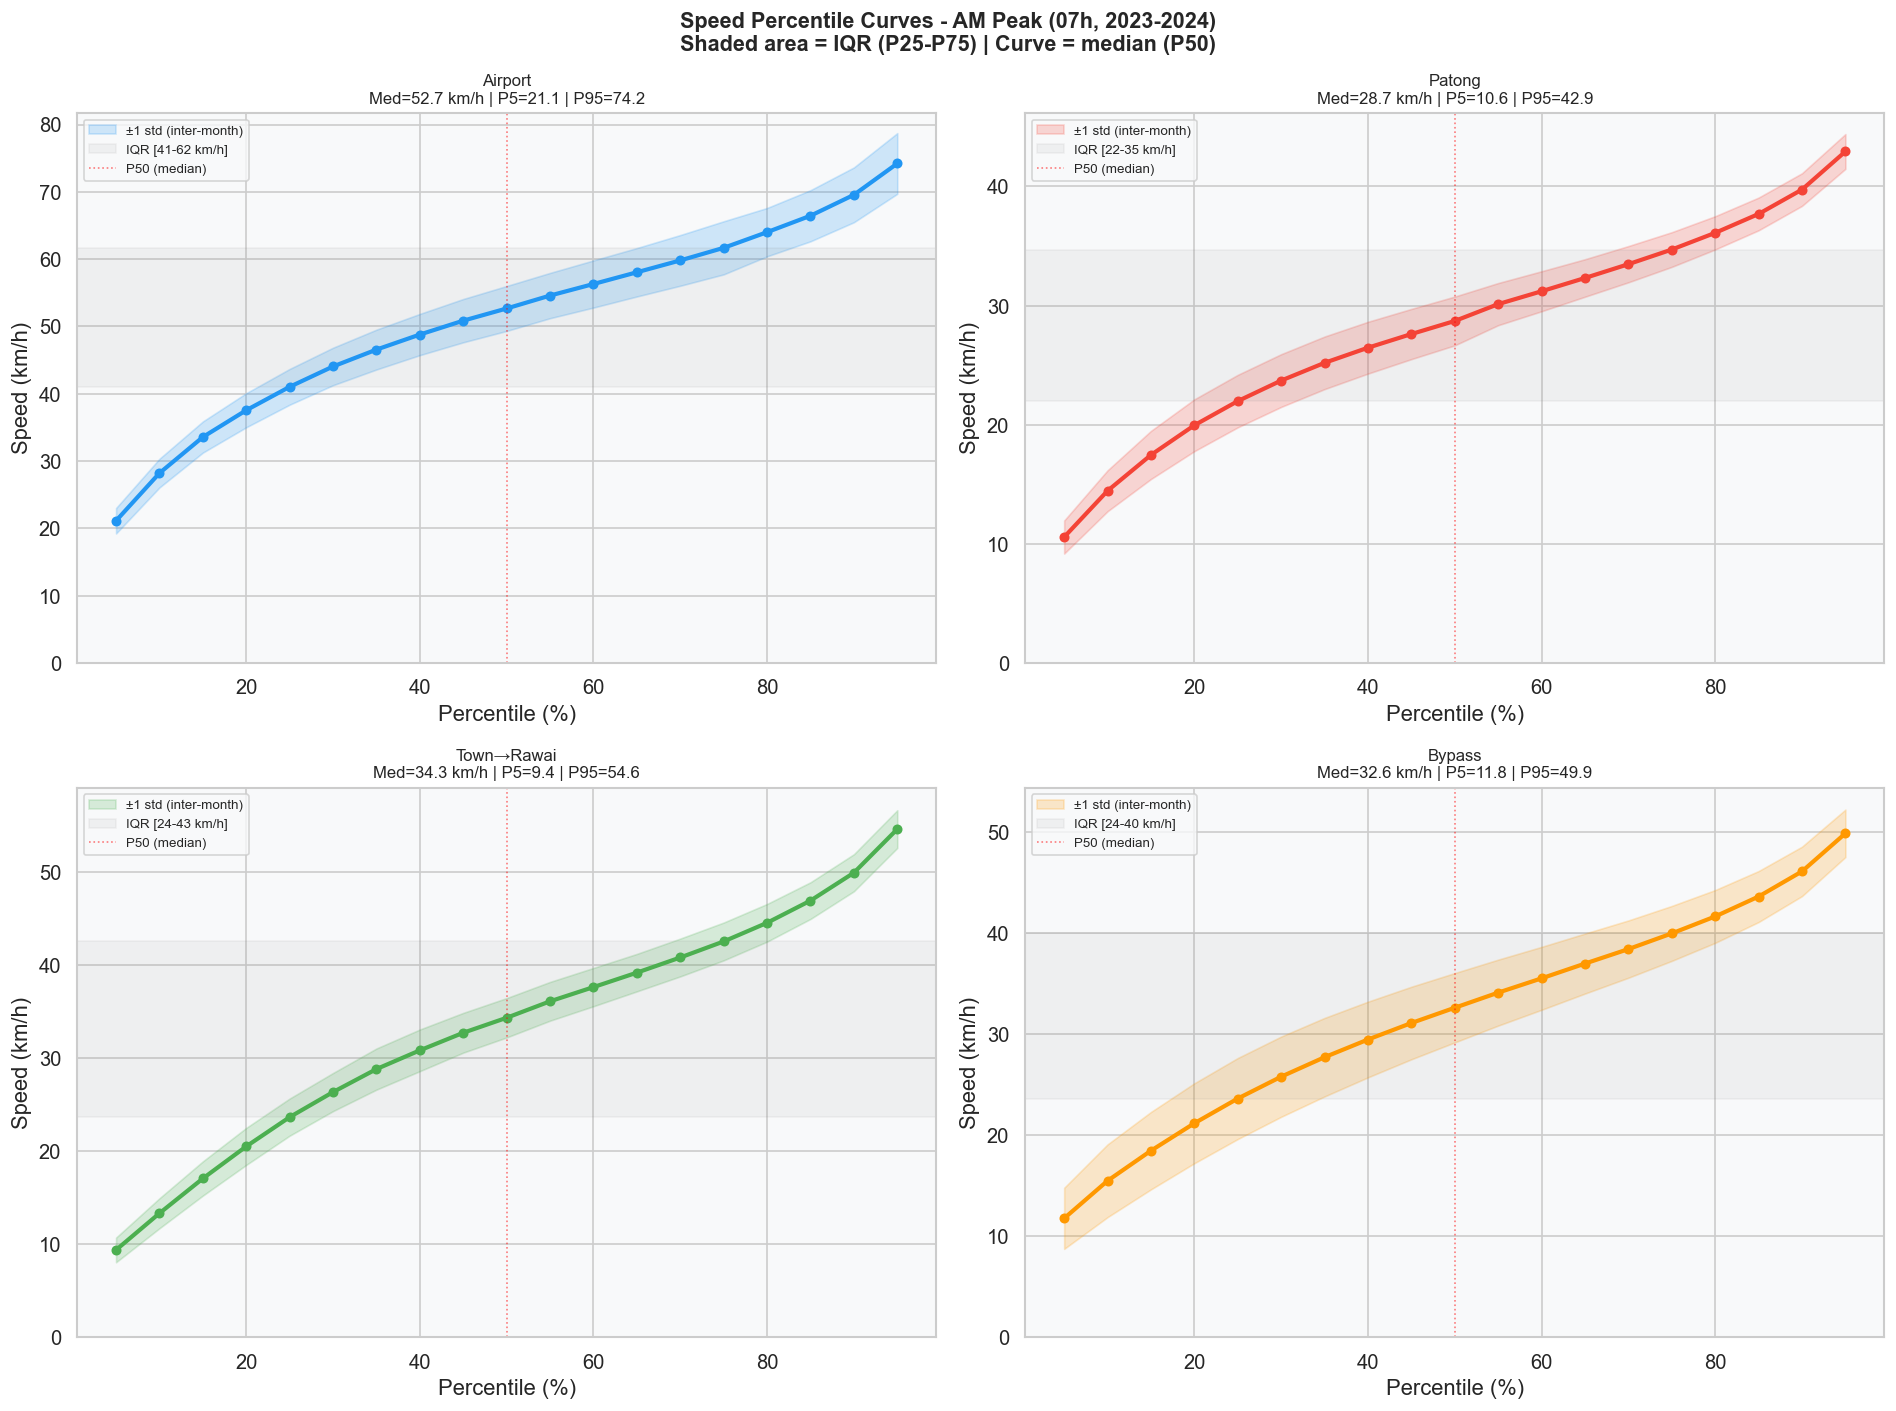

In [91]:
speed_pct_cols = [f'speed_p{p:02d}' for p in [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95]]
pct_values     = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95]

# AM Peak (Weekday_AM1) - corridor comparison
df_am = df_sum[df_sum['timeset_name']=='Weekday_AM1'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Speed Percentile Curves - AM Peak (07h, 2023-2024)\n'
             'Shaded area = IQR (P25-P75) | Curve = median (P50)', fontsize=13, fontweight='bold')

for ax, corridor in zip(axes.flat, CORRIDORS_ORDER):
    color = CORRIDOR_COLORS[corridor]
    sub = df_am[df_am['route_name']==corridor]
    if len(sub) == 0: continue
    pct_means = sub[speed_pct_cols].mean().values
    pct_stds  = sub[speed_pct_cols].std().values
    ax.plot(pct_values, pct_means, 'o-', color=color, linewidth=2.5, markersize=5)
    ax.fill_between(pct_values, pct_means-pct_stds, pct_means+pct_stds,
                    alpha=0.2, color=color, label='±1 std (inter-month)')
    # P25-P75 fill
    p25 = sub['speed_p25'].mean()
    p75 = sub['speed_p75'].mean()
    ax.axhspan(p25, p75, alpha=0.08, color='grey', label=f'IQR [{p25:.0f}-{p75:.0f} km/h]')
    ax.axvline(50, color='red', linestyle=':', linewidth=1, alpha=0.5, label='P50 (median)')
    ax.set_title(f'{CORRIDOR_SHORT[corridor]}\nMed={sub["speed_p50"].mean():.1f} km/h | P5={sub["speed_p05"].mean():.1f} | P95={sub["speed_p95"].mean():.1f}',
                 fontsize=10)
    ax.set_xlabel('Percentile (%)')
    ax.set_ylabel('Speed (km/h)')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_speed_percentiles_am.png', bbox_inches='tight', facecolor='white')
plt.show()

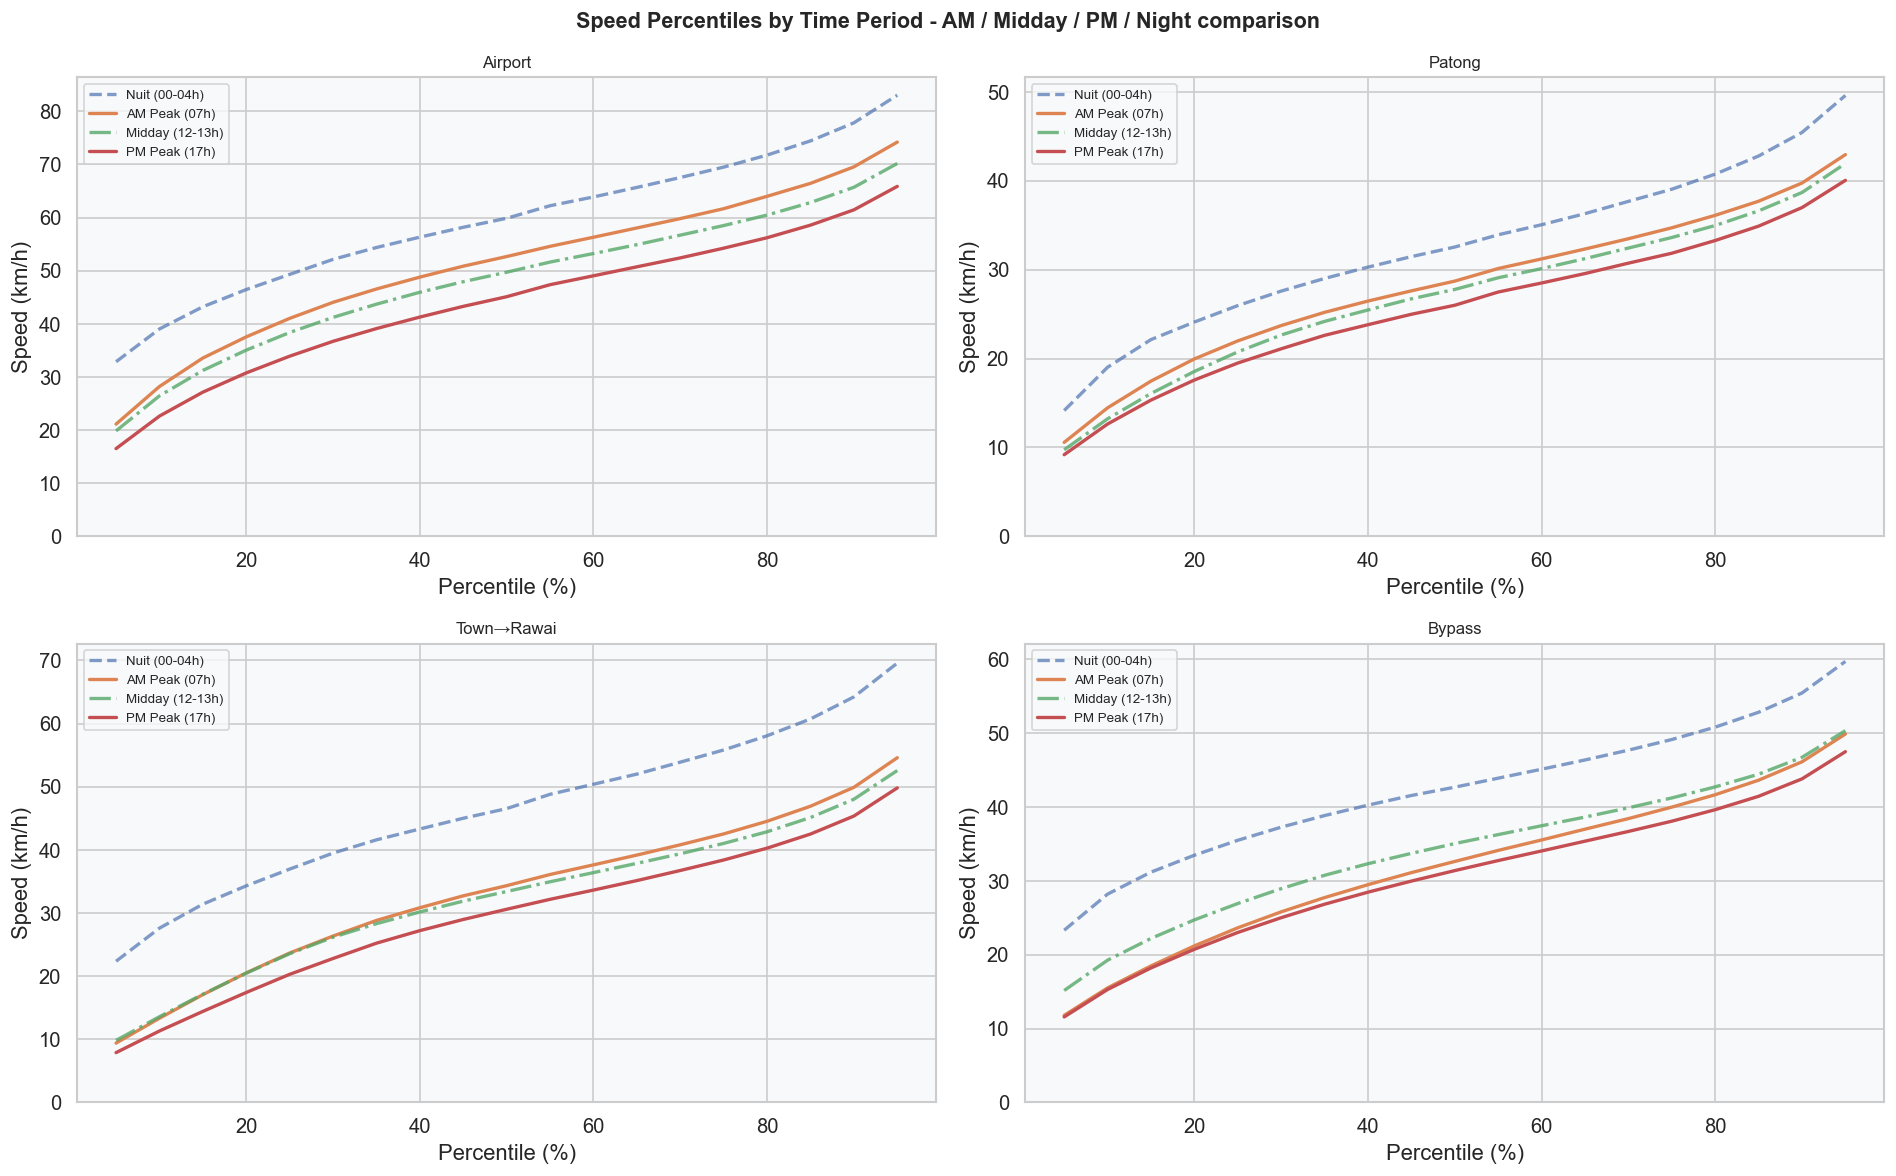

In [92]:
# Comparaison percentiles vitesse : AM Peak vs PM Peak vs Nuit
ts_compare = {
    'Weekday_Night': ('Nuit (00-04h)',    '--', 0.7),
    'Weekday_AM1'  : ('AM Peak (07h)',    '-',  1.0),
    'Weekday_Midday': ('Midday (12-13h)', '-.',  0.8),
    'Weekday_PM1'  : ('PM Peak (17h)',    '-',  1.0),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Speed Percentiles by Time Period - AM / Midday / PM / Night comparison',
             fontsize=13, fontweight='bold')

for ax, corridor in zip(axes.flat, CORRIDORS_ORDER):
    for ts, (label, ls, alpha) in ts_compare.items():
        sub = df_sum[(df_sum['route_name']==corridor) & (df_sum['timeset_name']==ts)]
        if len(sub) == 0: continue
        means = sub[speed_pct_cols].mean().values
        ax.plot(pct_values, means, linestyle=ls, linewidth=2, alpha=alpha, label=label)
    ax.set_title(CORRIDOR_SHORT[corridor], fontsize=10)
    ax.set_xlabel('Percentile (%)')
    ax.set_ylabel('Speed (km/h)')
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_speed_percentiles_compare.png', bbox_inches='tight')
plt.show()


## 4. Courbes de percentiles de temps de trajet (P5 → P95)

Écart P5-P95 large = corridor imprévisible (mauvaise fiabilité = PTI élevé).


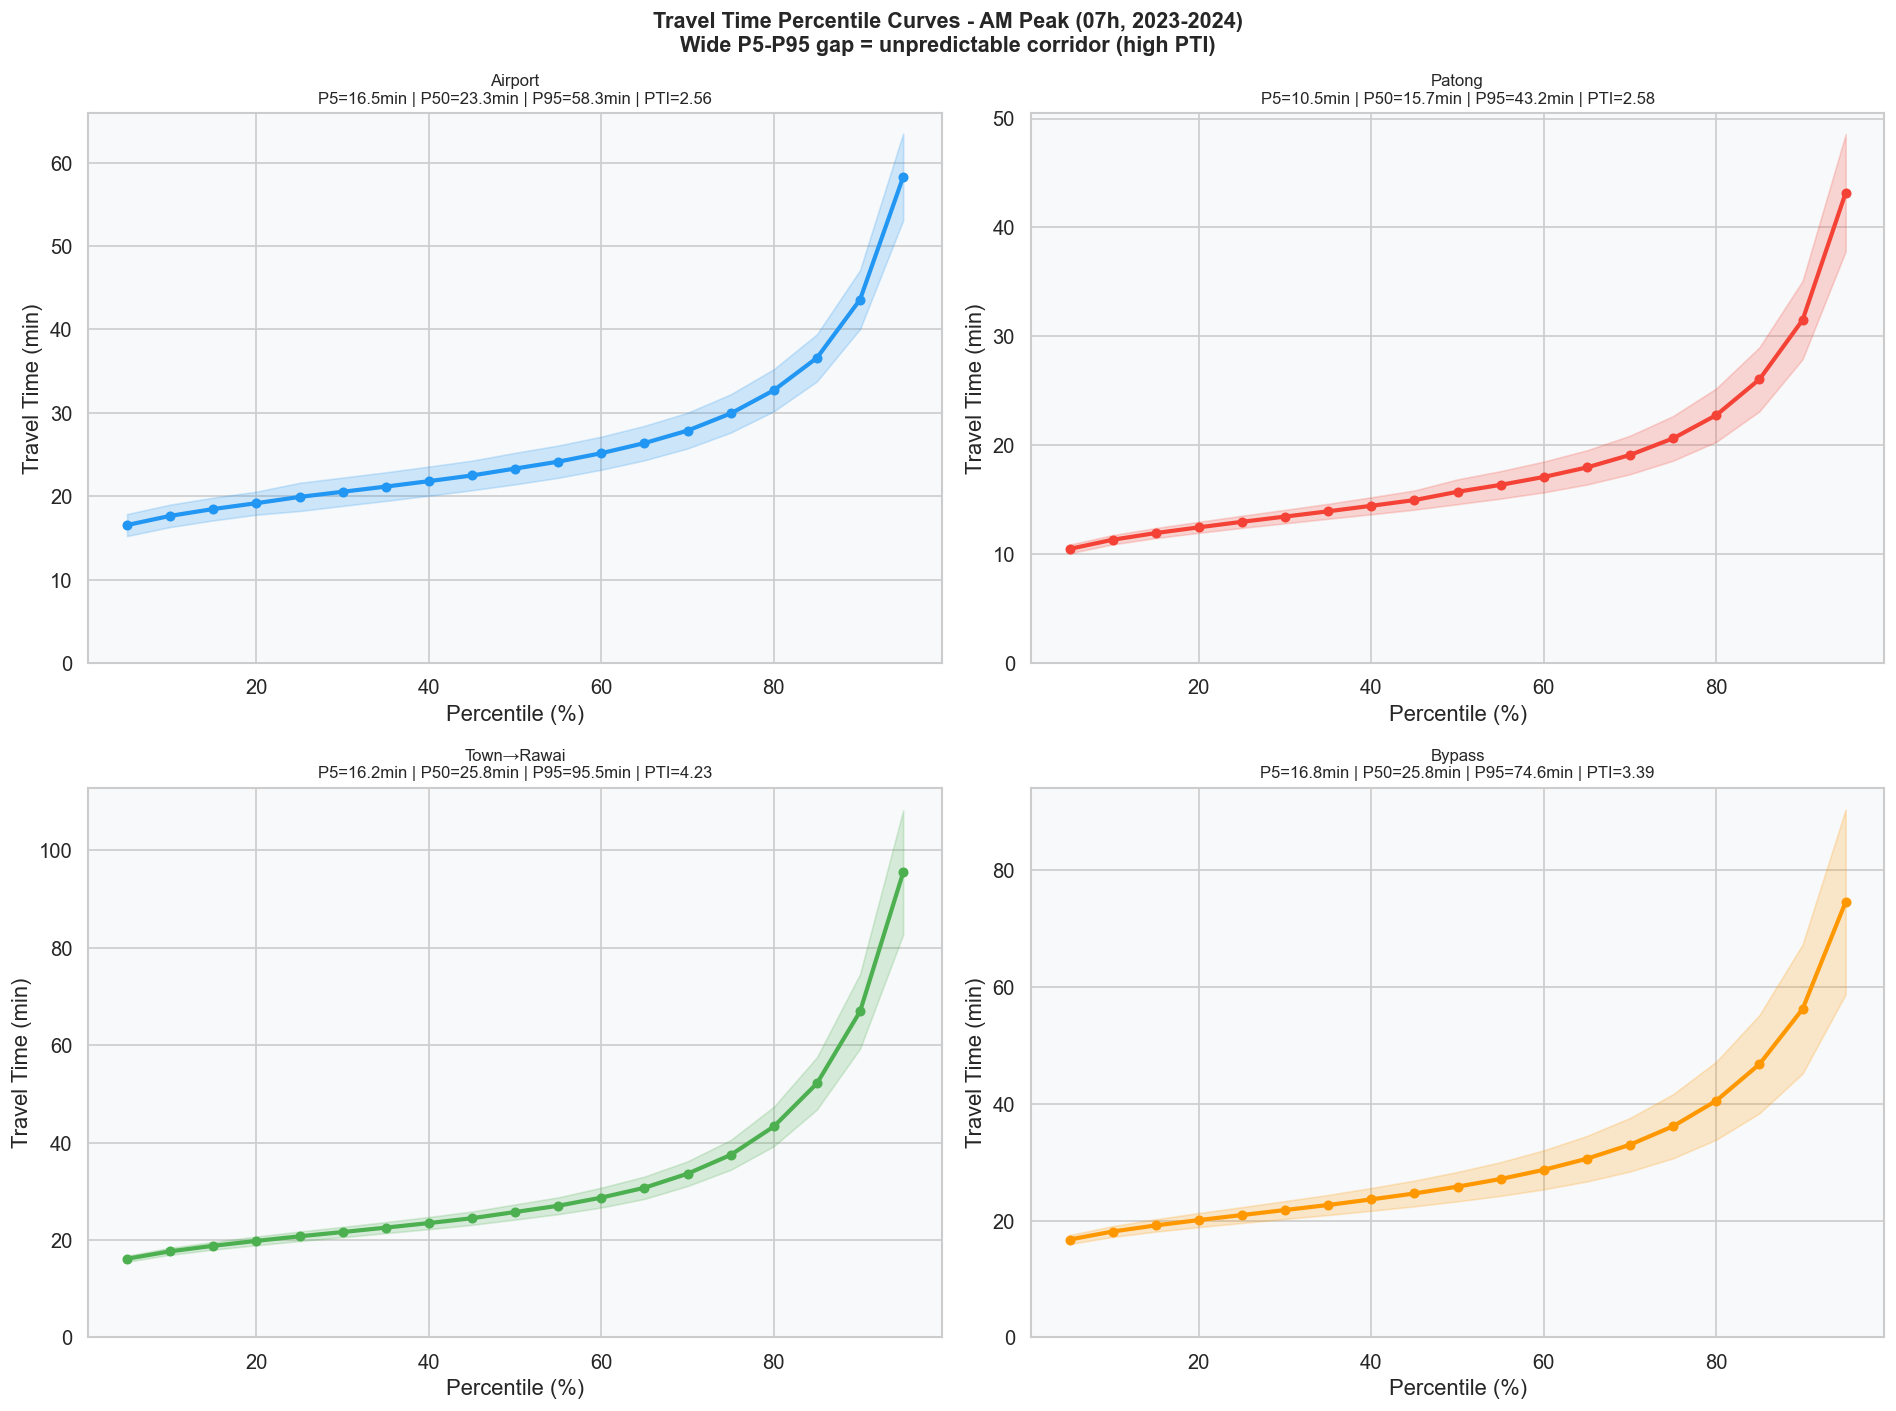

In [93]:
tt_pct_cols = [f'tt_p{p:02d}_s' for p in [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Travel Time Percentile Curves - AM Peak (07h, 2023-2024)\n'
             'Wide P5-P95 gap = unpredictable corridor (high PTI)', fontsize=13, fontweight='bold')

df_am = df_sum[df_sum['timeset_name']=='Weekday_AM1'].copy()

for ax, corridor in zip(axes.flat, CORRIDORS_ORDER):
    color = CORRIDOR_COLORS[corridor]
    sub = df_am[df_am['route_name']==corridor]
    if len(sub) == 0: continue
    pct_means = sub[tt_pct_cols].mean().values / 60  # seconds → minutes
    pct_stds  = sub[tt_pct_cols].std().values  / 60
    ax.plot(pct_values, pct_means, 'o-', color=color, linewidth=2.5, markersize=5)
    ax.fill_between(pct_values, pct_means-pct_stds, pct_means+pct_stds, alpha=0.2, color=color)
    p5_min  = sub['tt_p05_s'].mean()/60
    p95_min = sub['tt_p95_s'].mean()/60
    p50_min = sub['tt_p50_s'].mean()/60
    pti_val = sub['planning_time_index'].mean()
    ax.set_title(f'{CORRIDOR_SHORT[corridor]}\n'
                 f'P5={p5_min:.1f}min | P50={p50_min:.1f}min | P95={p95_min:.1f}min | PTI={pti_val:.2f}',
                 fontsize=10)
    ax.set_xlabel('Percentile (%)')
    ax.set_ylabel('Travel Time (min)')
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_tt_percentiles_am.png', bbox_inches='tight', facecolor='white')
plt.show()

## 5. PTI - Planning Time Index

`PTI = TT_P95 / TT_free_flow` - Plus élevé = plus de marge nécessaire pour arriver à l'heure.  
Analysé ici sur les 24 timesets × 24 mois × 4 corridors.


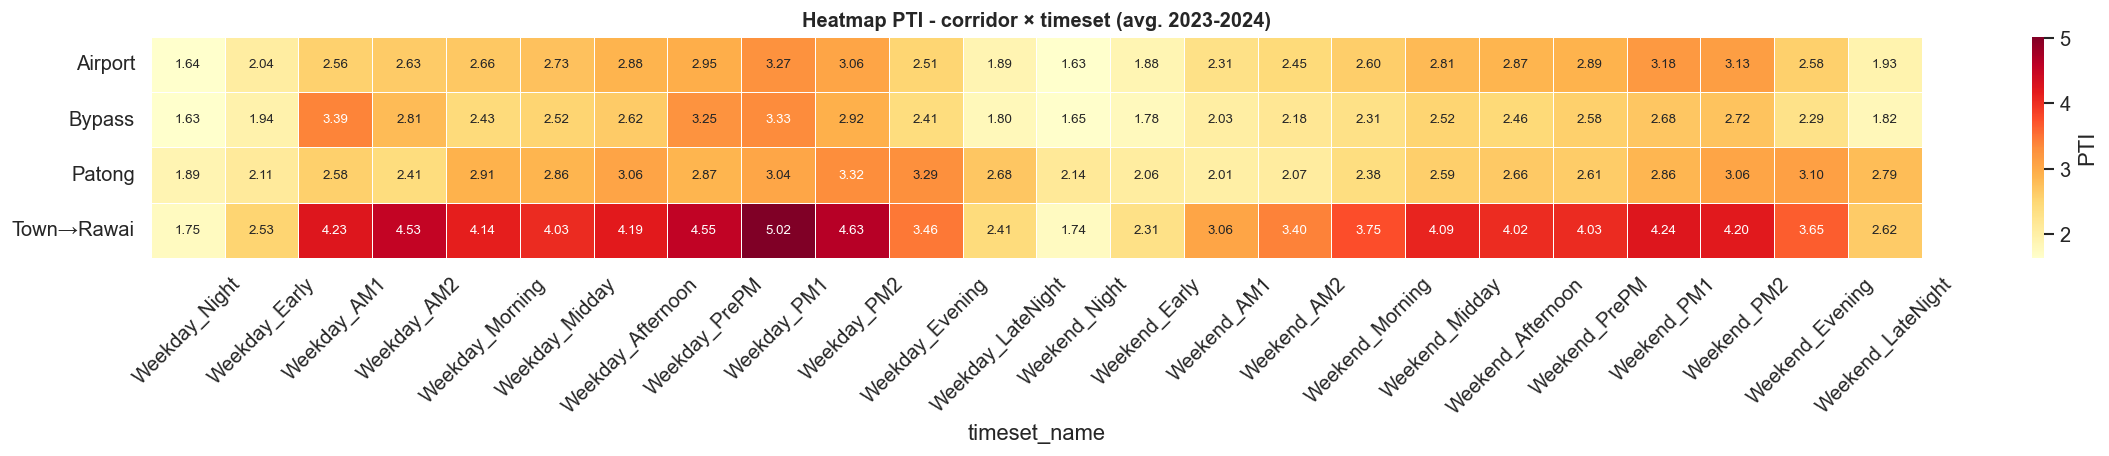

In [94]:
# Heatmap PTI - corridor × timeset
pivot_pti = df_sum.groupby(['route_name','timeset_name'])['planning_time_index'].mean().unstack()
pivot_pti = pivot_pti[ALL_TIMESETS]
pivot_pti.index = [CORRIDOR_SHORT[c] for c in pivot_pti.index]

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(pivot_pti, ax=ax, cmap='YlOrRd',
            annot=True, fmt='.2f', annot_kws={'size':8},
            linewidths=0.5, cbar_kws={'label':'PTI'})
ax.set_title('Heatmap PTI - corridor × timeset (avg. 2023-2024)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../final_data/figures/fig_heatmap_pti.png', bbox_inches='tight')
plt.show()


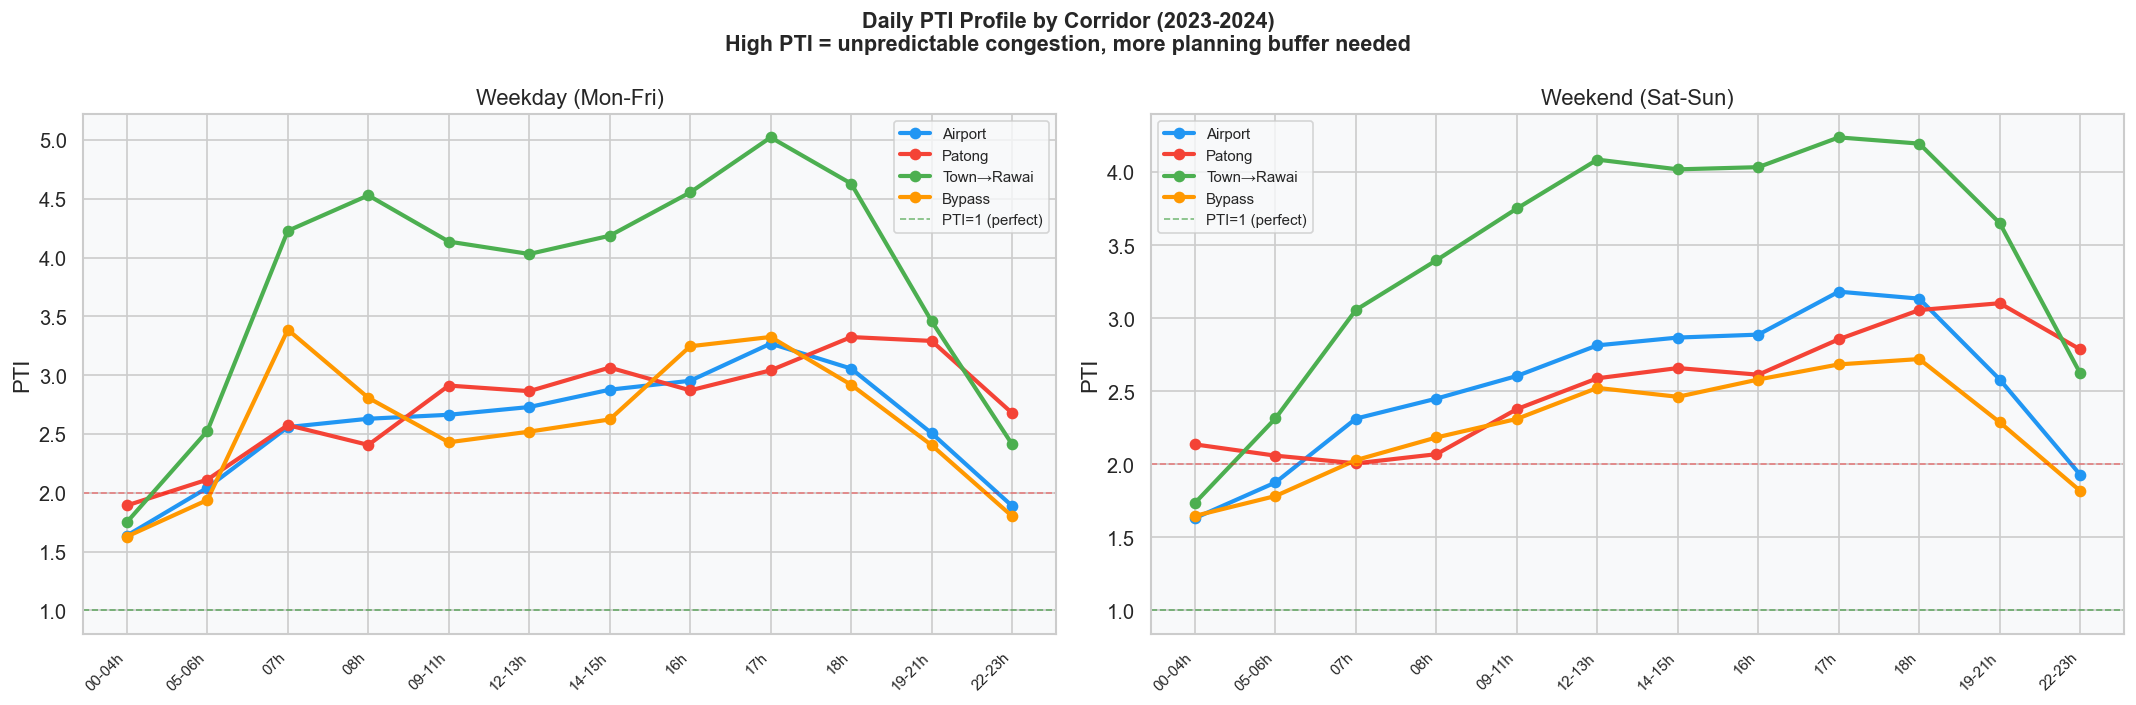

In [95]:
# PTI daily profile per corridor - weekday vs weekend
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Daily PTI Profile by Corridor (2023-2024)\n'
             'High PTI = unpredictable congestion, more planning buffer needed', fontsize=13, fontweight='bold')

for ax, (order, labels, title) in zip(axes, [
    (WEEKDAY_ORDER, WEEKDAY_LABELS, 'Weekday (Mon-Fri)'),
    (WEEKEND_ORDER, WEEKDAY_LABELS, 'Weekend (Sat-Sun)'),
]):
    for corr in CORRIDORS_ORDER:
        sub   = df_sum[df_sum['route_name']==corr]
        means = [sub[sub['timeset_name']==ts]['planning_time_index'].mean() for ts in order]
        ax.plot(range(len(order)), means, 'o-', linewidth=2.5, markersize=6,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
    ax.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='PTI=1 (perfect)')
    ax.axhline(2.0, color='red',   linestyle='--', linewidth=1, alpha=0.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('PTI')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_pti_profile.png', bbox_inches='tight', facecolor='white')
plt.show()

In [96]:
# PTI stats par corridor - tableau de synthèse
pti_stats = df_sum.groupby('route_name')['planning_time_index'].agg(['mean','std','min','max']).round(3)
pti_stats.index = [CORRIDOR_SHORT[c] for c in pti_stats.index]

# Pire timeset par corridor
pti_worst = df_sum.groupby(['route_name','timeset_name'])['planning_time_index'].mean().reset_index()
worst = pti_worst.loc[pti_worst.groupby('route_name')['planning_time_index'].idxmax()]
worst['corridor_short'] = worst['route_name'].map(CORRIDOR_SHORT)
pti_stats['Pire timeset'] = worst.set_index('corridor_short')['timeset_name']
pti_stats['PTI max ts']   = worst.set_index('corridor_short')['planning_time_index'].round(3)

print('Synthèse PTI par corridor (2023-2024) :')
display(pti_stats)


Synthèse PTI par corridor (2023-2024) :


,mean,std,min,max,Pire timeset,PTI max ts
Airport,2.545,0.514,1.44,3.93,Weekday_PM1,3.269
Bypass,2.419,0.542,1.55,4.56,Weekday_AM1,3.387
Patong,2.640,0.530,1.59,4.54,Weekday_PM2,3.325
Town→Rawai,3.607,0.983,1.49,5.68,Weekday_PM1,5.022


## 6. Évolution temporelle (2023-2024)


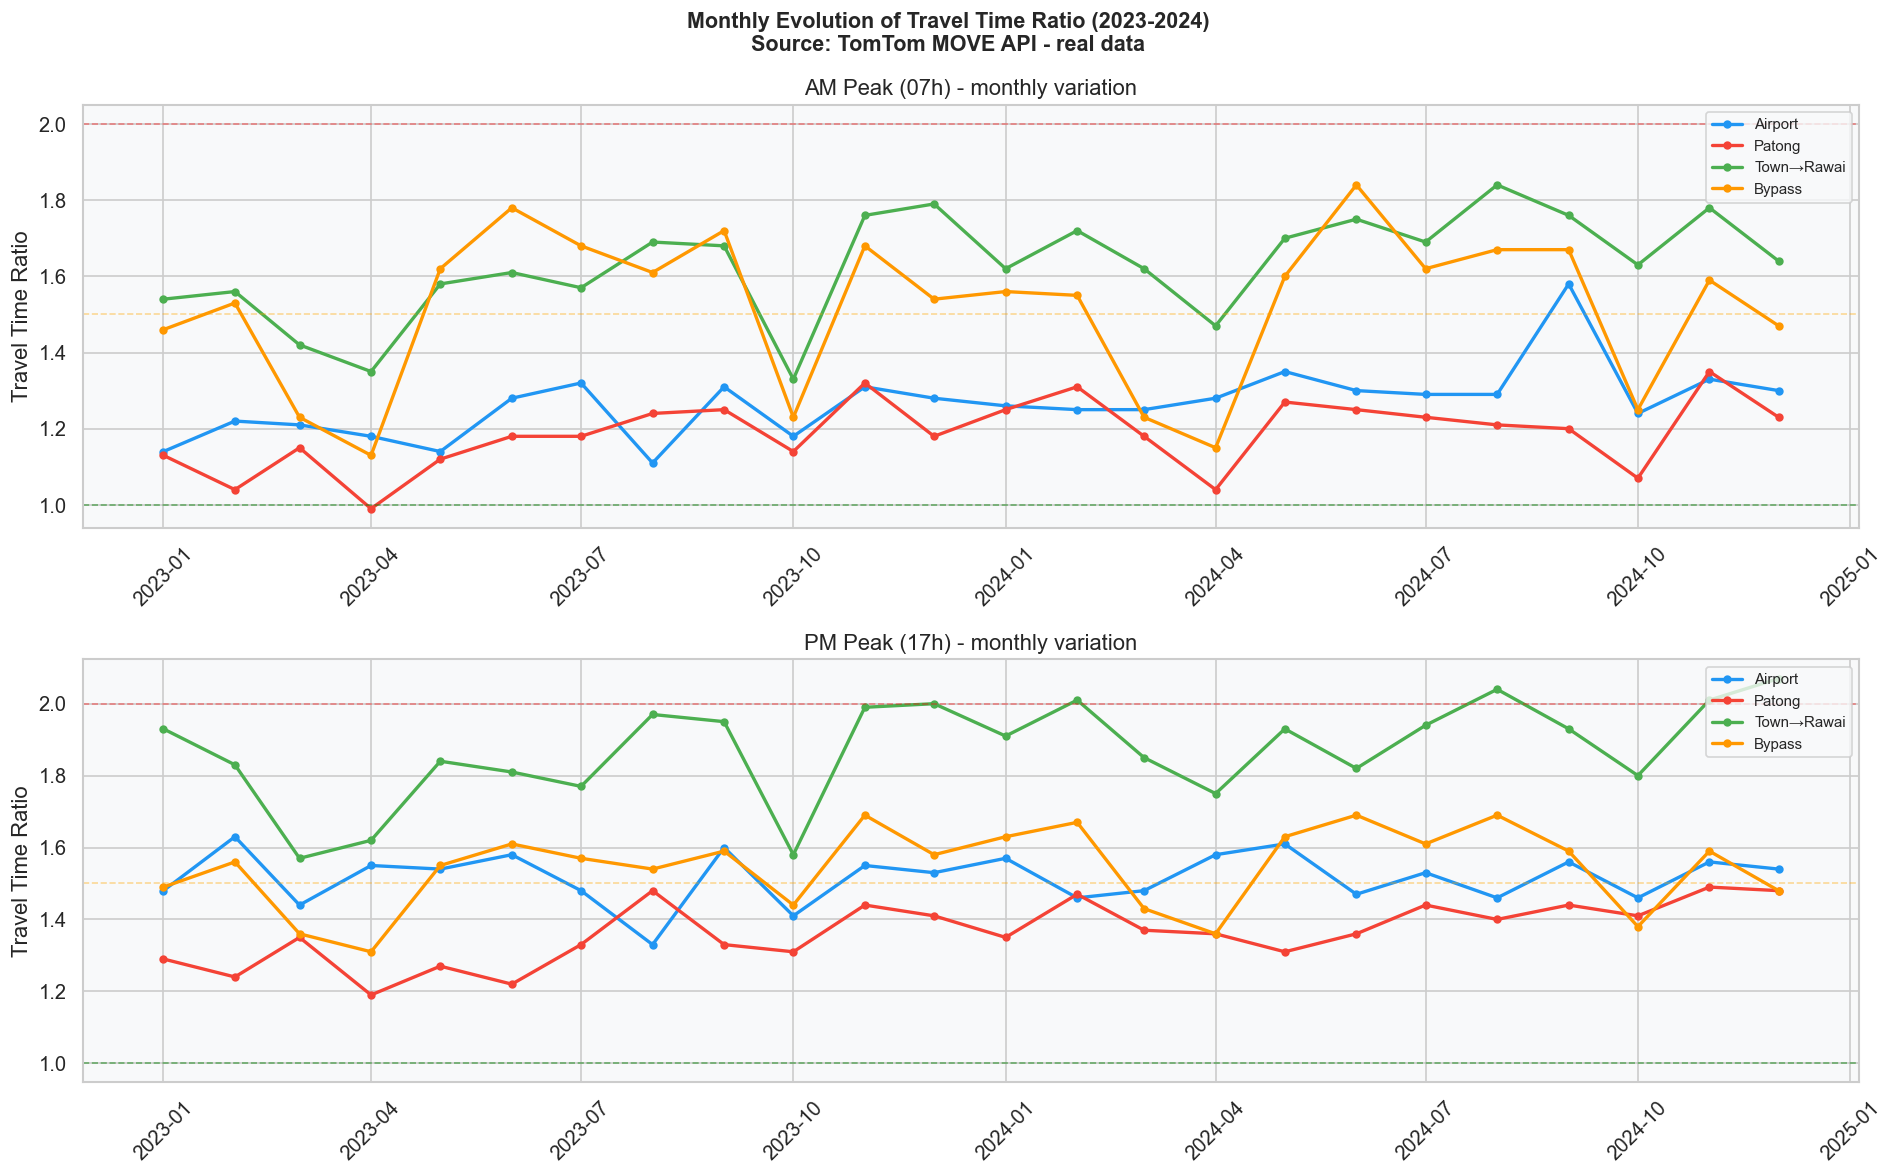

In [97]:
# Monthly evolution of TTR - AM Peak and PM Peak, all corridors
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Monthly Evolution of Travel Time Ratio (2023-2024)\n'
             'Source: TomTom MOVE API - real data', fontsize=13, fontweight='bold')

for ax, ts in zip(axes, ['Weekday_AM1','Weekday_PM1']):
    sub_ts = df_sum[df_sum['timeset_name']==ts].sort_values('month_date')
    for corr in CORRIDORS_ORDER:
        s = sub_ts[sub_ts['route_name']==corr]
        ax.plot(s['month_date'], s['avg_travel_time_ratio'], 'o-', linewidth=2, markersize=4,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
    ax.axhline(1.0, color='green',  linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(1.5, color='orange', linestyle='--', linewidth=1, alpha=0.4)
    ax.axhline(2.0, color='red',    linestyle='--', linewidth=1, alpha=0.4)
    ts_label = 'AM Peak (07h)' if ts=='Weekday_AM1' else 'PM Peak (17h)'
    ax.set_title(f'{ts_label} - monthly variation')
    ax.set_ylabel('Travel Time Ratio')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('../final_data/figures/fig_temporal_ttr_raw.png', bbox_inches='tight', facecolor='white')
plt.show()

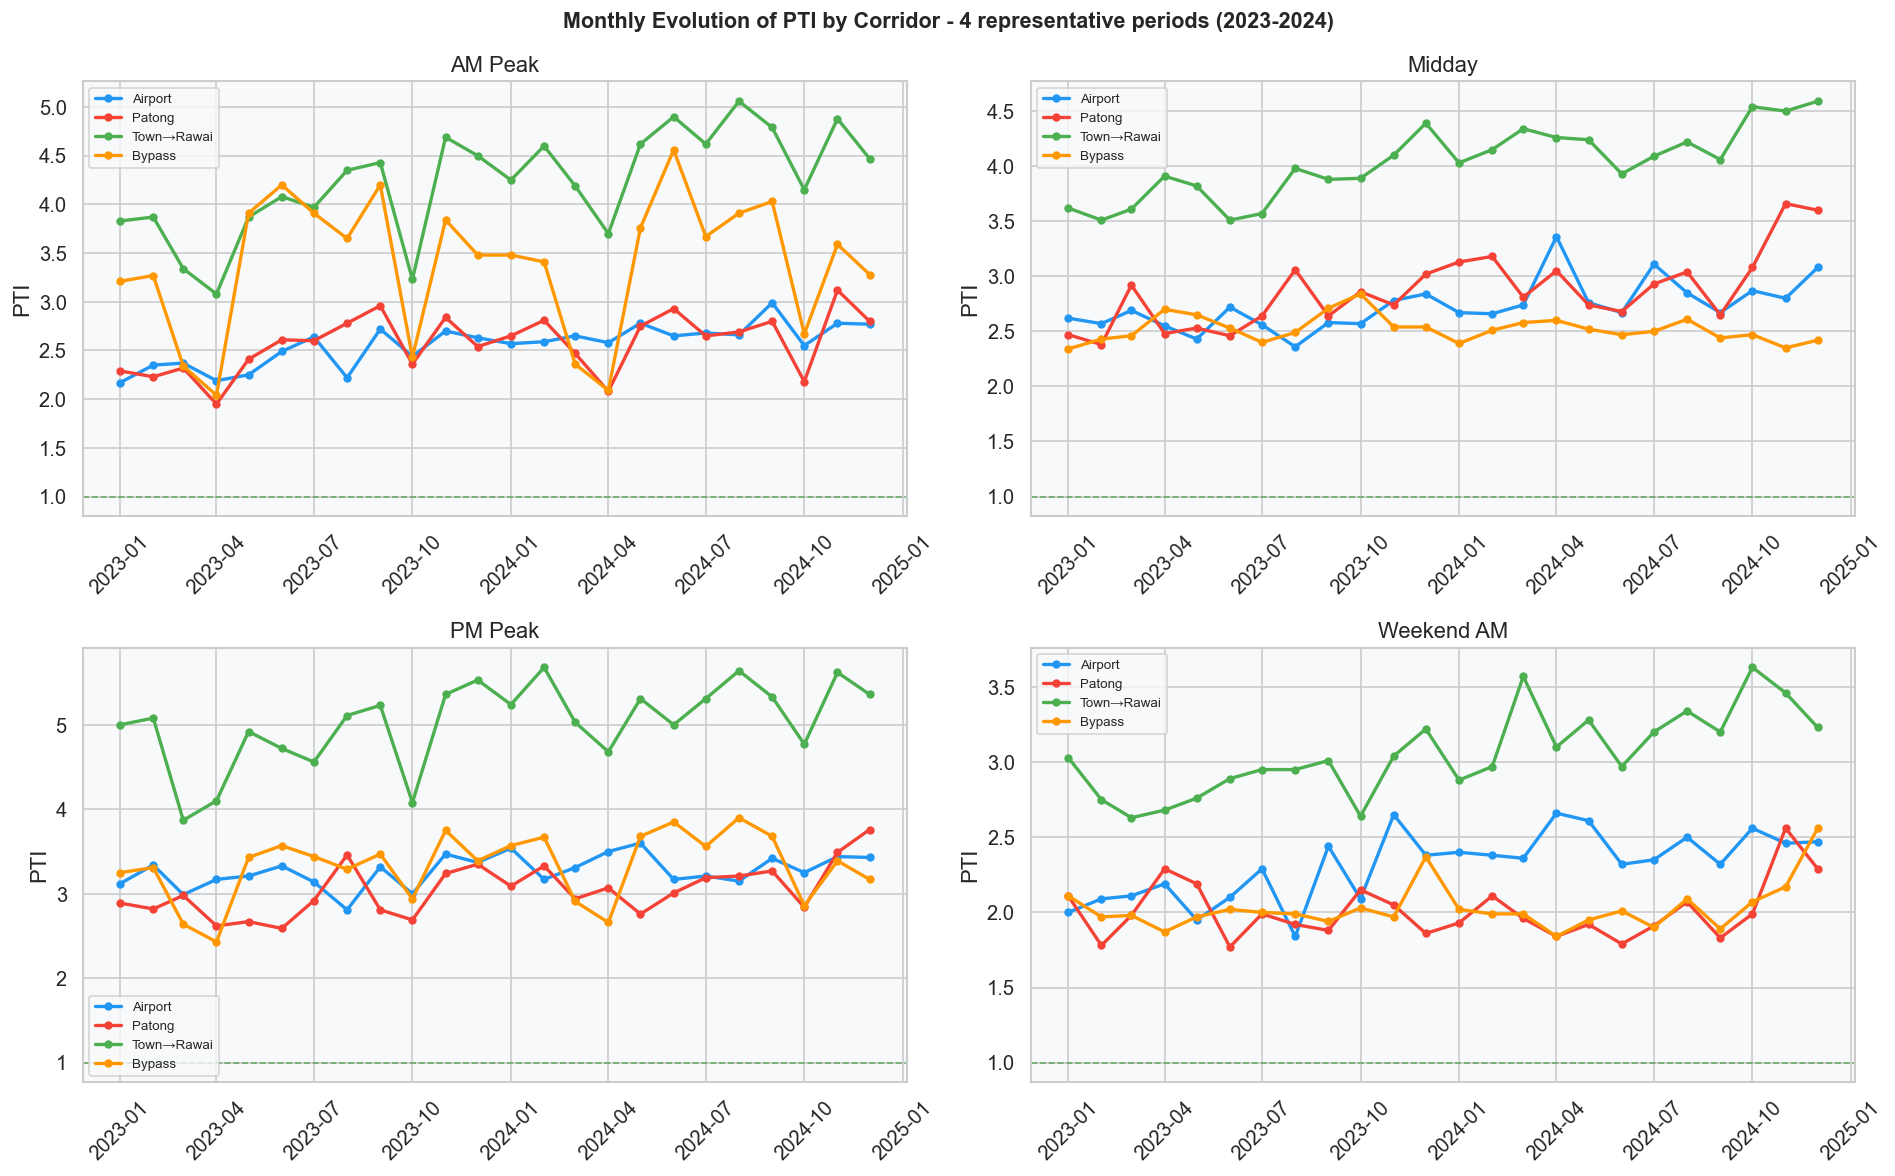

In [98]:
# Évolution mensuelle PTI - par corridor, 4 timesets représentatifs
rep_ts = ['Weekday_AM1','Weekday_Midday','Weekday_PM1','Weekend_AM1']
rep_labels = {'Weekday_AM1':'AM Peak','Weekday_Midday':'Midday','Weekday_PM1':'PM Peak','Weekend_AM1':'Weekend AM'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Evolution of PTI by Corridor - 4 representative periods (2023-2024)',
             fontsize=13, fontweight='bold')

for ax, ts in zip(axes.flat, rep_ts):
    sub_ts = df_sum[df_sum['timeset_name']==ts].sort_values('month_date')
    for corr in CORRIDORS_ORDER:
        s = sub_ts[sub_ts['route_name']==corr]
        ax.plot(s['month_date'], s['planning_time_index'], 'o-', linewidth=2, markersize=4,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
    ax.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(rep_labels[ts])
    ax.set_ylabel('PTI')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_temporal_pti.png', bbox_inches='tight')
plt.show()


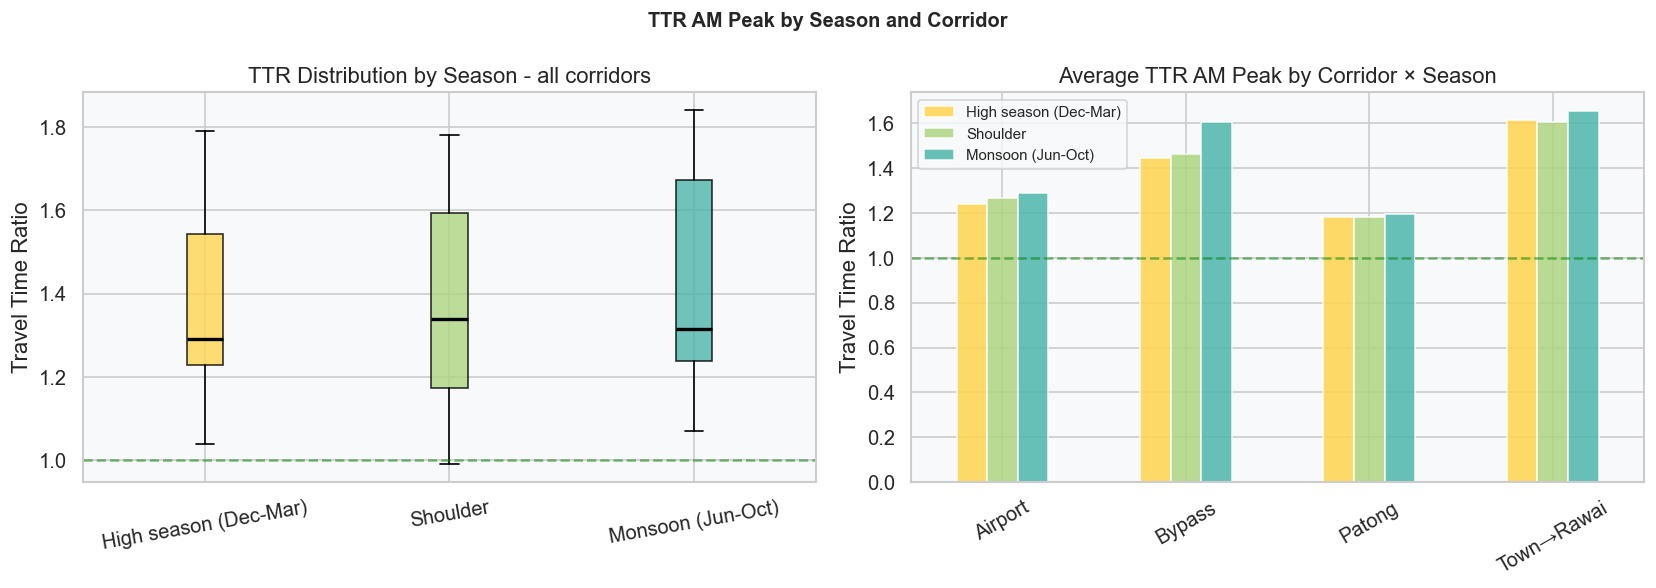

In [99]:
# Variation saisonnière - TTR AM Peak by Season and Corridor
df_am_all = df_sum[df_sum['timeset_name']=='Weekday_AM1'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TTR AM Peak by Season and Corridor', fontsize=12, fontweight='bold')
season_colors = {'high_peak':'#FFD54F','shoulder':'#AED581','monsoon':'#4DB6AC'}

# Boxplot par saison
ax = axes[0]
for i, season in enumerate(SEASON_ORDER):
    sub_s = df_am_all[df_am_all['season']==season]['avg_travel_time_ratio']
    ax.boxplot(sub_s, positions=[i], patch_artist=True,
               boxprops={'facecolor':season_colors[season],'alpha':0.8},
               medianprops={'color':'black','linewidth':2})
ax.set_xticks(range(len(SEASON_ORDER)))
ax.set_xticklabels([SEASON_LABELS[s] for s in SEASON_ORDER], rotation=10)
ax.set_title('TTR Distribution by Season - all corridors')
ax.set_ylabel('Travel Time Ratio')
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5)

# Barres TTR moyen par corridor × saison
ax = axes[1]
season_corr = df_am_all.groupby(['route_name','season'])['avg_travel_time_ratio'].mean().unstack()
season_corr.index = [CORRIDOR_SHORT[c] for c in season_corr.index]
season_corr[SEASON_ORDER].plot(kind='bar', ax=ax,
    color=[season_colors[s] for s in SEASON_ORDER], alpha=0.85, edgecolor='white')
ax.set_title('Average TTR AM Peak by Corridor × Season')
ax.set_ylabel('Travel Time Ratio')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend([SEASON_LABELS[s] for s in SEASON_ORDER], fontsize=9)
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_ttr_by_season.png', bbox_inches='tight')
plt.show()


## 7. Analyse des segments (segments_all.csv)


In [100]:
print(f"segments_all.csv : {df_seg.shape[0]:,} lignes × {df_seg.shape[1]} cols")
print(f"Colonnes : {df_seg.columns.tolist()}")
print(f"Timesets disponibles : {sorted(df_seg['timeset_name'].unique())}")
print(f"Corridors : {sorted(df_seg['route_name'].unique())}")
df_seg.head(3)


segments_all.csv : 537,408 lignes × 52 cols
Colonnes : ['source_file', 'job_name', 'created_at', 'route_name', 'probe_source', 'zone_id', 'segment_id', 'new_segment_id', 'speed_limit', 'frc', 'distance_m', 'start_lat', 'start_lon', 'mid_lat', 'mid_lon', 'end_lat', 'end_lon', 'n_shape_pts', 'timeset_id', 'timeset_name', 'daterange_id', 'daterange_name', 'date_from', 'date_to', 'harmonic_avg_speed', 'median_speed', 'avg_speed', 'avg_travel_time_s', 'median_travel_time_s', 'travel_time_ratio', 'sample_size', 'norm_sample_size', 'speed_p05', 'speed_p10', 'speed_p15', 'speed_p20', 'speed_p25', 'speed_p30', 'speed_p35', 'speed_p40', 'speed_p45', 'speed_p50', 'speed_p55', 'speed_p60', 'speed_p65', 'speed_p70', 'speed_p75', 'speed_p80', 'speed_p85', 'speed_p90', 'speed_p95', 'congestion_ratio']
Timesets disponibles : ['Weekday_AM1', 'Weekday_AM2', 'Weekday_Afternoon', 'Weekday_Early', 'Weekday_Evening', 'Weekday_LateNight', 'Weekday_Midday', 'Weekday_Morning', 'Weekday_Night', 'Weekday_PM1', '

,source_file,job_name,created_at,route_name,probe_source,zone_id,segment_id,new_segment_id,speed_limit,frc,...,speed_p55,speed_p60,speed_p65,speed_p70,speed_p75,speed_p80,speed_p85,speed_p90,speed_p95,congestion_ratio
0,jobs_8977013_results_Phuket_4corridors_24month...,Phuket_4corridors_24months_24timesets,2026-04-04T11:43:46.436979571Z,Airport Road (Route 402),ALL,Asia/Bangkok,-17640063984056,-83d62335-e3fe-4f6f-b269-4a20d261fe07,30,7,...,0,0,0,0,0,0,0,0,0,0.0
1,jobs_8977013_results_Phuket_4corridors_24month...,Phuket_4corridors_24months_24timesets,2026-04-04T11:43:46.436979571Z,Airport Road (Route 402),ALL,Asia/Bangkok,-17640063984056,-83d62335-e3fe-4f6f-b269-4a20d261fe07,30,7,...,0,0,0,0,0,0,0,0,0,0.0
2,jobs_8977013_results_Phuket_4corridors_24month...,Phuket_4corridors_24months_24timesets,2026-04-04T11:43:46.436979571Z,Airport Road (Route 402),ALL,Asia/Bangkok,-17640063984056,-83d62335-e3fe-4f6f-b269-4a20d261fe07,30,7,...,0,0,0,0,0,0,0,0,0,0.0


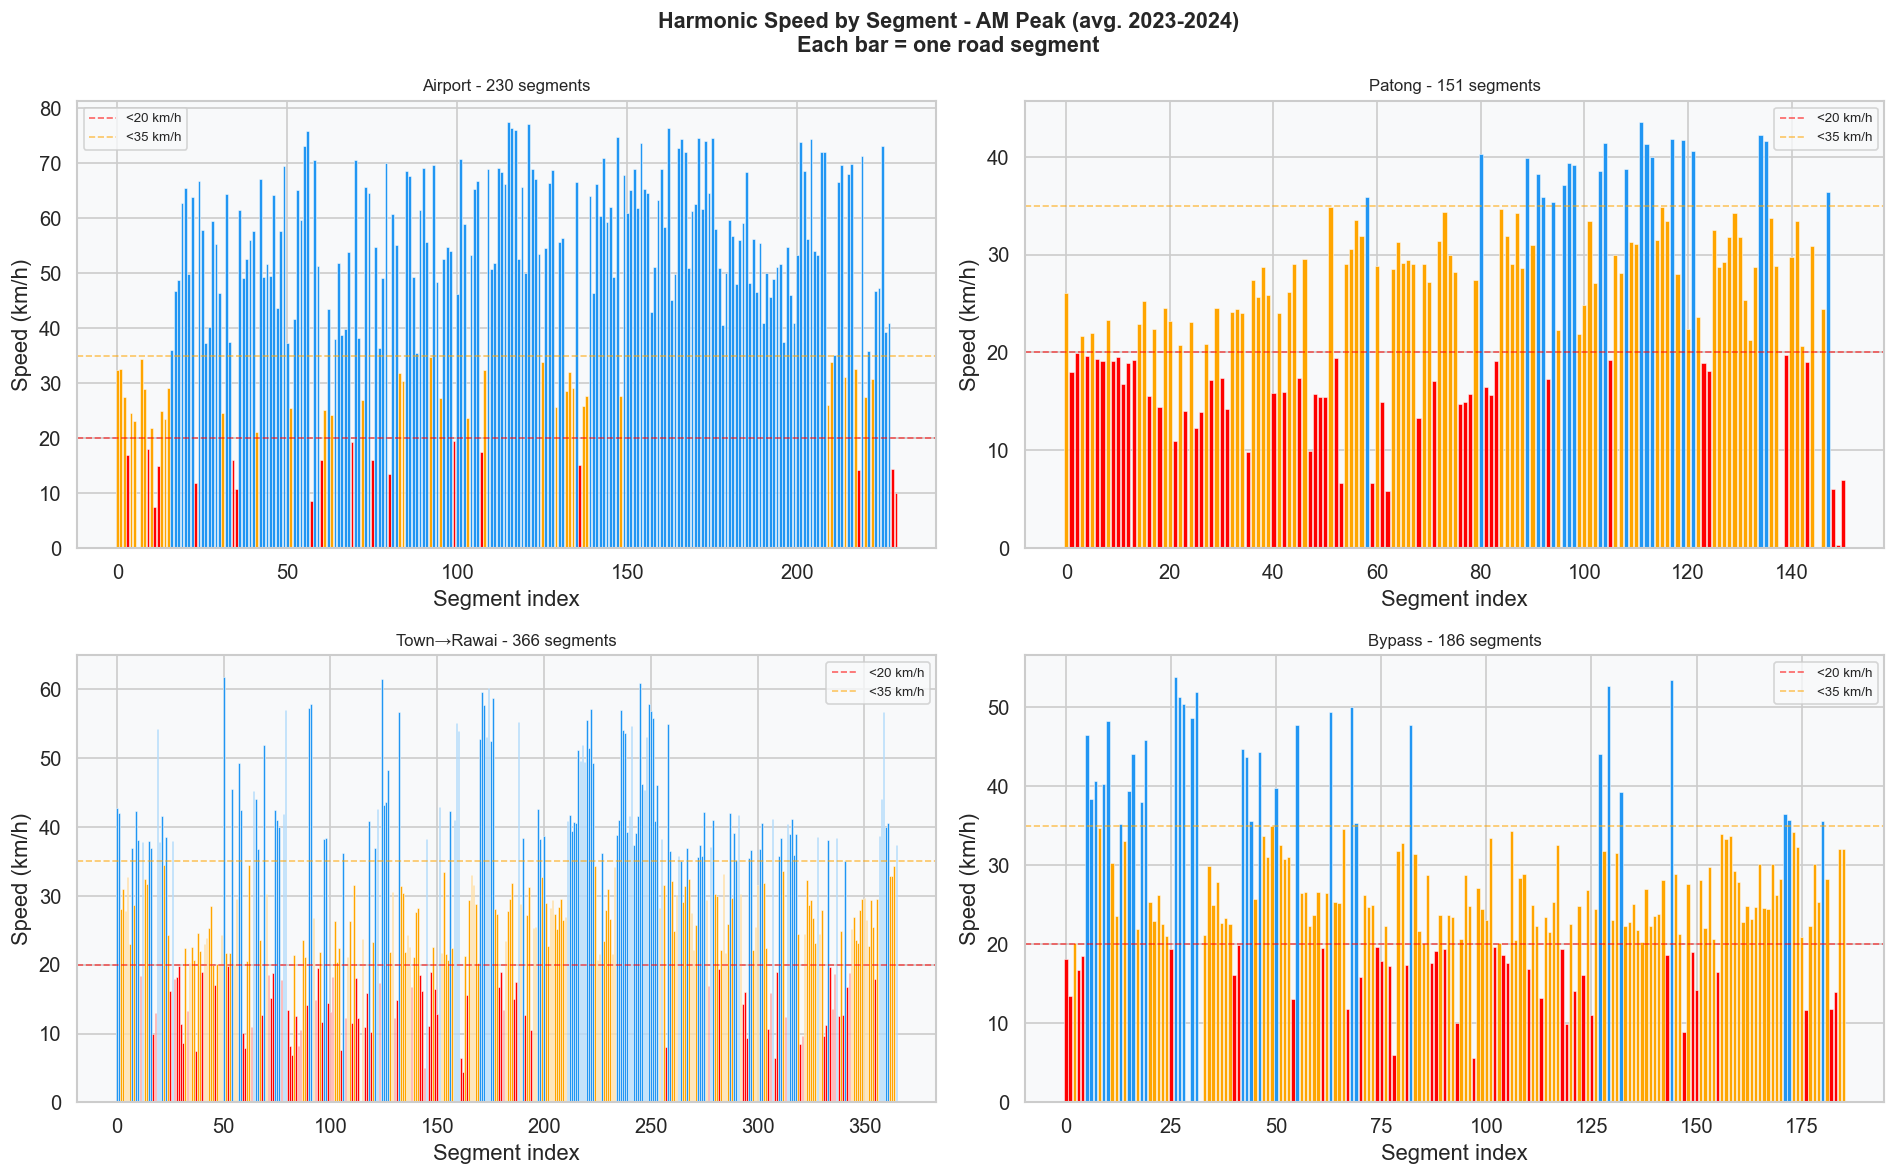

In [101]:
# Speed profile per segment - AM Peak (Weekday_AM1 + AM2), avg. 2023-2024
am_ts = [ts for ts in ['Weekday_AM1','Weekday_AM2'] if ts in df_seg['timeset_name'].unique()]
seg_am = df_seg[df_seg['timeset_name'].isin(am_ts)].copy()

spd_col = 'harmonic_avg_speed' if 'harmonic_avg_speed' in seg_am.columns else None
if spd_col is None:
    spd_col = next((c for c in seg_am.columns if 'speed' in c.lower() and 'limit' not in c.lower()), None)

if spd_col:
    seg_grp = seg_am.groupby(['route_name','segment_id'])[spd_col].mean().reset_index()
    seg_grp['corridor_short'] = seg_grp['route_name'].map(CORRIDOR_SHORT)
    seg_grp['seg_idx'] = seg_grp.groupby('route_name').cumcount()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Harmonic Speed by Segment - AM Peak (avg. 2023-2024)\n'
                 'Each bar = one road segment', fontsize=13, fontweight='bold')

    for ax, corr in zip(axes.flat, CORRIDORS_ORDER):
        sub = seg_grp[seg_grp['route_name']==corr].sort_values('segment_id')
        if len(sub)==0:
            ax.set_visible(False); continue
        colors_seg = ['red' if v < 20 else 'orange' if v < 35 else '#2196F3'
                      for v in sub[spd_col]]
        ax.bar(range(len(sub)), sub[spd_col], color=colors_seg, edgecolor='white', linewidth=0.3)
        ax.set_title(f'{CORRIDOR_SHORT[corr]} - {len(sub)} segments', fontsize=10)
        ax.set_xlabel('Segment index')
        ax.set_ylabel('Speed (km/h)')
        ax.axhline(20, color='red',    linestyle='--', linewidth=1, alpha=0.6, label='<20 km/h')
        ax.axhline(35, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='<35 km/h')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('../final_data/figures/fig_segments_speed.png', bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print('Speed column not found in segments_all.csv')
    print('Available columns:', df_seg.columns.tolist())

## 8. Synthèse & Points clés pour la thèse


In [102]:
print('=' * 70)
print('SYNTHÈSE PROFILS TOMTOM - POINTS CLÉS POUR LA THÈSE')
print('=' * 70)

print('\n📊 DONNÉES')
print(f'  Source   : TomTom MOVE API')
print(f'  Période  : {df_sum["daterange_name"].min()} → {df_sum["daterange_name"].max()} ({df_sum["daterange_name"].nunique()} mois)')
print(f'  Couverture : {df_sum["route_name"].nunique()} corridors × {df_sum["daterange_name"].nunique()} mois × {df_sum["timeset_name"].nunique()} timesets')
print(f'  Résumés : {df_sum.shape[0]:,} lignes | Segments : {df_seg.shape[0]:,} lignes')

print('\n🚗 CORRIDORS - CLASSEMENT PAR TTR AM PEAK')
ranking_ttr = df_sum[df_sum['timeset_name']=='Weekday_AM1'].groupby('route_name')['avg_travel_time_ratio'].mean().sort_values(ascending=False)
for i, (corr, val) in enumerate(ranking_ttr.items(), 1):
    print(f'  {i}. {CORRIDOR_SHORT[corr]:12s} → TTR={val:.3f}')

print('\n📈 PTI - PIRE CRÉNEAU PAR CORRIDOR')
for corr in CORRIDORS_ORDER:
    sub = df_sum[df_sum['route_name']==corr]
    pti_by_ts = sub.groupby('timeset_name')['planning_time_index'].mean()
    worst_ts  = pti_by_ts.idxmax()
    worst_val = pti_by_ts.max()
    best_ts   = pti_by_ts.idxmin()
    best_val  = pti_by_ts.min()
    print(f'  {CORRIDOR_SHORT[corr]:12s} → max PTI: {worst_ts} ({worst_val:.2f}) | min: {best_ts} ({best_val:.2f})')

print('\n⏰ AMPLITUDE JOURNALIÈRE (TTR max - TTR min) - SEMAINE')
for corr in CORRIDORS_ORDER:
    sub = df_sum[(df_sum['route_name']==corr) & (df_sum['is_weekday'])]
    ttr_by_ts = sub.groupby('timeset_name')['avg_travel_time_ratio'].mean()
    amplitude = ttr_by_ts.max() - ttr_by_ts.min()
    peak_ts   = ttr_by_ts.idxmax()
    print(f'  {CORRIDOR_SHORT[corr]:12s} → amplitude={amplitude:.3f} | pic: {peak_ts} (TTR={ttr_by_ts.max():.3f})')

print('\n✅ PROCHAINE ÉTAPE : 03_prepare_dataset.ipynb → features ML')


SYNTHÈSE PROFILS TOMTOM - POINTS CLÉS POUR LA THÈSE

📊 DONNÉES
  Source   : TomTom MOVE API
  Période  : 2023_01 → 2024_12 (24 mois)
  Couverture : 4 corridors × 24 mois × 24 timesets
  Résumés : 2,304 lignes | Segments : 537,408 lignes

🚗 CORRIDORS - CLASSEMENT PAR TTR AM PEAK
  1. Town→Rawai   → TTR=1.629
  2. Bypass       → TTR=1.517
  3. Airport      → TTR=1.267
  4. Patong       → TTR=1.188

📈 PTI - PIRE CRÉNEAU PAR CORRIDOR
  Airport      → max PTI: Weekday_PM1 (3.27) | min: Weekend_Night (1.63)
  Patong       → max PTI: Weekday_PM2 (3.32) | min: Weekday_Night (1.89)
  Town→Rawai   → max PTI: Weekday_PM1 (5.02) | min: Weekend_Night (1.74)
  Bypass       → max PTI: Weekday_AM1 (3.39) | min: Weekday_Night (1.63)

⏰ AMPLITUDE JOURNALIÈRE (TTR max - TTR min) - SEMAINE
  Airport      → amplitude=0.517 | pic: Weekday_PM1 (TTR=1.517)
  Patong       → amplitude=0.486 | pic: Weekday_Evening (TTR=1.486)
  Town→Rawai   → amplitude=0.872 | pic: Weekday_PM1 (TTR=1.872)
  Bypass       → amplit